In [1]:
from pathlib import Path
notebook_dir = Path().resolve()
data_path = notebook_dir.parent / "DataSet" / "secom.csv"
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score, r2_score, mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, _tree
from xgboost import XGBClassifier, XGBRegressor


PCA 保留 131 個主成分
cluster sizes: {0: 1563, 1: 4}
cluster     0  1
y               
0        1460  3
1         103  1


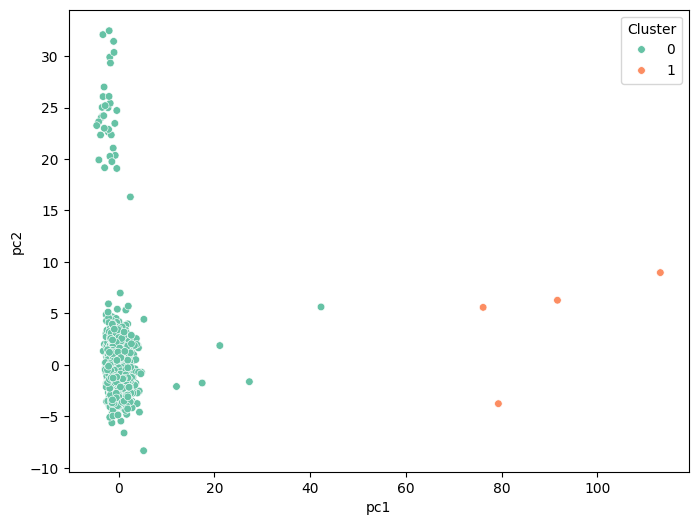

In [3]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, 132)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['Cluster'] = labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='Cluster', s=30, palette='Set2')
plt.show()

PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個
PCA 保留 133 個主成分
cluster sizes: {0: 948, 1: 1197}
cluster    0    1
y                
0        743  687
1        205  510


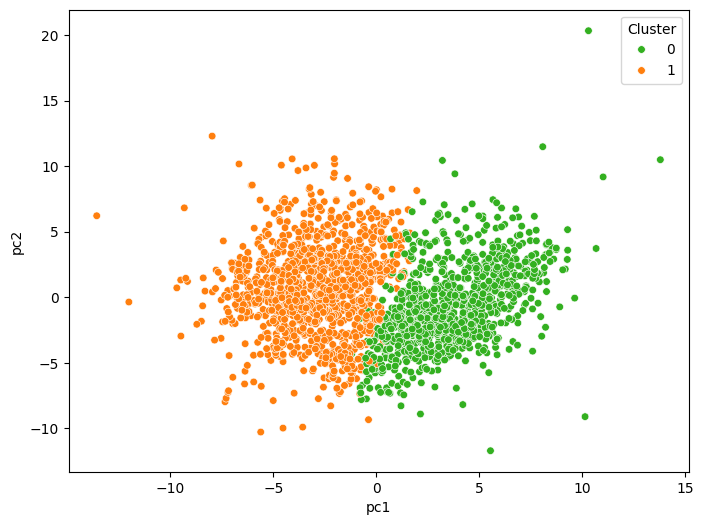

In [4]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_smote)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y_smote.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['Cluster'] = labels

plt.figure(figsize=(8,6))
palette = {
    0: "#33B020",  # cluster 0, y=1
    1: '#ff7f0e',  # cluster 1, y=0
}
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='Cluster', s=30, palette=palette)
plt.show()


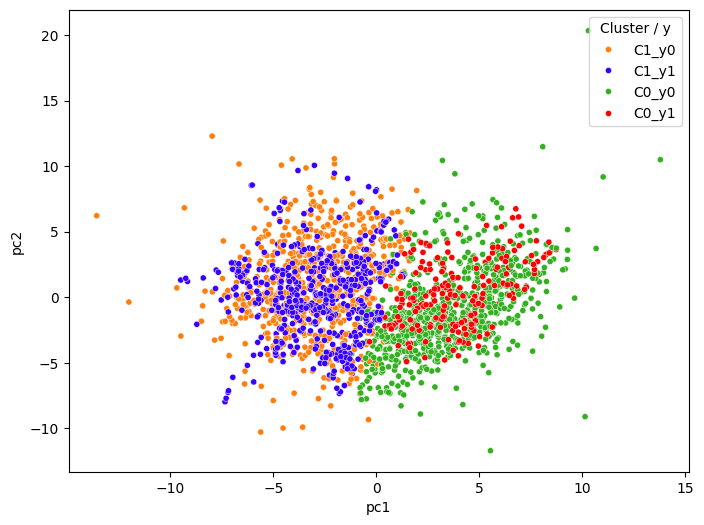

In [6]:
X_pca_df['y'] = y_smote.values

# 建一個 4 類別欄位： (cluster, y)
X_pca_df['group'] = (
    'C' + X_pca_df['Cluster'].astype(str) + '_y' + X_pca_df['y'].astype(str)
)
# 這樣會有：C0_y0, C0_y1, C1_y0, C1_y1 四種

plt.figure(figsize=(8,6))
# 自訂 4 種顏色（可自行調整）
palette = {
    'C0_y0': "#33B020",  # cluster 0, y=0
    'C0_y1': "#ff0000",  # cluster 0, y=1
    'C1_y0': '#ff7f0e',  # cluster 1, y=0
    'C1_y1': "#3700ff",  # cluster 1, y=1
}
sns.scatterplot(
    data=X_pca_df,
    x='pc1', y='pc2',
    hue='group',
    palette=palette,
    s=20
)
plt.legend(title='Cluster / y', loc='best')
plt.show()

---
---

In [9]:
def local_surrogate(
    x0,
    blackbox_model,
    scaler=None,
    n_samples=1000,
    sigma=1,
    surrogate_type=None,
    random_state=None,
):
    """
    x0: 1D array-like, 原始特徵空間中的設計點
    blackbox_model: 已訓練好的黑箱模型, 需有 predict_proba 或 predict
    scaler: 已 fit 好的標準化物件 (如 StandardScaler). 若 None 則不做 scaling
    n_samples: 在 x0 鄰域內要產生的設計點數 M
    sigma: 在「標準化空間」中的擾動標準差
    surrogate_type: "linear" (線性迴歸) 或 "tree" (決策樹迴歸)
    """
    rng = np.random.default_rng(random_state)

    # 1) x0 -> 標準化空間
    x0 = np.asarray(x0).reshape(1, -1)
    if scaler is not None:
        x0_scaled = scaler.transform(x0)
    else:
        x0_scaled = x0.copy()

    n_features = x0_scaled.shape[1]

    # 2) 在標準化空間中, 以 N(x0, sigma^2 I) 產生鄰域設計點 Z_scaled
    eps = rng.normal(loc=0.0, scale=sigma, size=(n_samples, n_features))
    Z_scaled = x0_scaled + eps

    # 3) 還原回原始空間 Z (給 surrogate 用的自變數)
    if scaler is not None:
        Z = scaler.inverse_transform(Z_scaled)
    else:
        Z = Z_scaled

    # 4) 用黑箱模型當 oracle 產生 pseudo-label
    if hasattr(blackbox_model, "predict_proba"):
        # 二元分類, 取 class=1 機率當連續目標
        p = blackbox_model.predict_proba(Z)[:, 1]
        y_local = p
    else:
        # 沒有 predict_proba 就直接用 predict 的連續輸出
        y_local = blackbox_model.predict(Z)

    # 5) 在 (Z, y_local) 上 fit 一個簡單 surrogate
    if surrogate_type == "logistic":
        surrogate = LogisticRegression(max_iter=2000, class_weight="balanced", penalty="l1", solver="liblinear", random_state=42)

    elif surrogate_type == "tree":
        surrogate = DecisionTreeRegressor(max_depth=6, min_samples_leaf=2, random_state=random_state)

    elif surrogate_type == 'xgb':
        surrogate = XGBRegressor(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')

    else:
        raise ValueError("surrogate_type must be 'someone'")

    surrogate.fit(Z, y_local)

    # 6) 衡量 surrogate 對黑箱在鄰域的擬合程度
    y_hat_local = surrogate.predict(Z)
    mse = mean_squared_error(y_local, y_hat_local)
    r2 = r2_score(y_local, y_hat_local)

    info = {
        "mse": mse,
        "r2": r2,
        "Z": Z,                     # 鄰域設計點 (原始空間)
        "y_blackbox": y_local,      # 黑箱輸出
        "y_surrogate": y_hat_local  # surrogate 輸出
    }

    return surrogate, info


---
---

In [ ]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)

X_train, X_test, y_train, y_test = train_test_split(X_smote, y_smote, test_size=0.3, random_state=42)
# xgbc = XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
logitR = LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42)
clf = logitR.fit(X_train, y_train)
y_pred_prob = clf.predict_proba(X_test)[:, 1]

# 1) 找到最接近 0.5 的測試點
delta = np.abs(y_pred_prob - 0.5)
idx0 = int(np.argmin(delta))

# 2) 取該點作為 x0
x0 = X_test.iloc[idx0].values

print("chosen idx =", idx0)
print("p(x0) =", y_pred_prob[idx0])
print("|p-0.5| =", delta[idx0])

# 3) local surrogate
sur_model, info = local_surrogate(
    x0=x0,
    blackbox_model=clf,
    scaler=None, # 目前空間已標準化
    n_samples=500,
    sigma=1,
    surrogate_type="tree", # 或其他
    random_state=42
)

print("local R2 =", info["r2"])
print("local MSE =", info["mse"])

PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個
chosen idx = 398
p(x0) = 0.500352889529595
|p-0.5| = 0.00035288952959500186
local R2 = 0.808606293704415
local MSE = 0.04053738257974798


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個


C:\Users\USER\AppData\Local\Temp\ipykernel_11796\3018557804.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_smote_df["cluster"] = cluster
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarnin

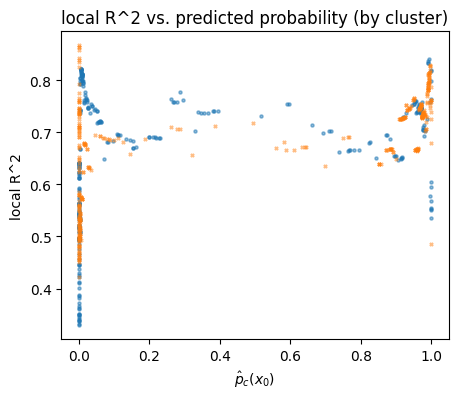

In [ ]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)

# X_smote, y_smote 已經是你前面做完 SMOTE 後的標準化空間資料
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

# 1) 在同一個 SMOTE 空間做 PCA + KMeans，得到 cluster
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_smote_df)

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
cluster = kmeans.fit_predict(X_pca)

X_smote_df["cluster"] = cluster

# 2) 切 train/test（cluster 也一起切）
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_smote_df, y_smote, test_size=0.3, random_state=42, stratify=y_smote)

# 拿出特徵矩陣（不含 cluster 欄）
X_train = X_train_df.drop(columns=["cluster"])
X_test  = X_test_df.drop(columns=["cluster"])
c_train = X_train_df["cluster"].to_numpy()
c_test  = X_test_df["cluster"].to_numpy()

# 3) 分群各自 fit black-box：f0, f1
def fit_blackbox_per_cluster(X_train, y_train, c_train):
    models = {}
    for c in [0, 1]:
        idx = np.where(c_train == c)[0]
        Xc = X_train.iloc[idx]
        yc = np.asarray(y_train)[idx]

        m = LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42)
        models[c] = m.fit(Xc, yc)
    return models

blackbox = fit_blackbox_per_cluster(X_train, y_train, c_train)

# 4) 分群跑 local surrogate：每個 x0 用對應的 f_c
records = []

for c in [0, 1]:
    idx_c = np.where(c_test == c)[0]
    X_test_c = X_test.iloc[idx_c]

    clf_c = blackbox[c]
    p_hat_c = clf_c.predict_proba(X_test_c)[:, 1]

    for j, i_global in enumerate(idx_c):
        x0 = X_test.iloc[i_global].values  # 同一個 SMOTE 空間座標系

        sur_model, info = local_surrogate(
            x0=x0,
            blackbox_model=clf_c,   # 重要：用該 cluster 的 black-box
            scaler=None,
            n_samples=500,
            sigma=1,
            surrogate_type="tree",
            random_state=42
        )

        records.append({
            "cluster": int(c),
            "local_R2": info["r2"],
            "local_MSE": info["mse"],
            "p_hat": float(p_hat_c[j]),
            "test_index": int(i_global)
        })

local_df = pd.DataFrame(records)


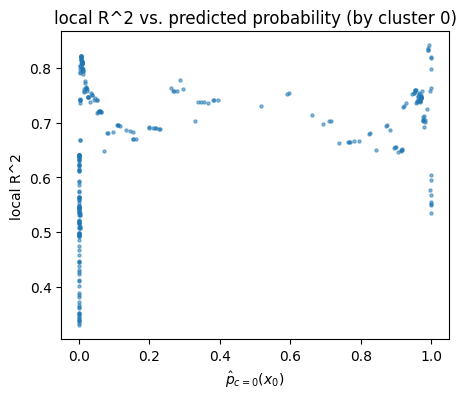

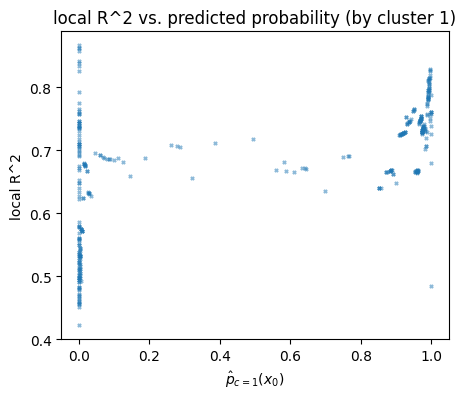

In [18]:
# 5) 畫圖（同一張圖疊兩群；不靠顏色就用不同 marker）
m0 = local_df["cluster"] == 0
m1 = local_df["cluster"] == 1
plt.figure(figsize=(5,4))

plt.scatter(local_df.loc[m0, "p_hat"], local_df.loc[m0, "local_R2"], s=5, alpha=0.5, marker="o")
plt.xlabel(r"$\hat p_{c=0}(x_0)$")
plt.ylabel("local R^2")
plt.title("local R^2 vs. predicted probability (by cluster 0)")
plt.show()

plt.figure(figsize=(5,4))
plt.scatter(local_df.loc[m1, "p_hat"], local_df.loc[m1, "local_R2"], s=5, alpha=0.5, marker="x")
plt.xlabel(r"$\hat p_{c=1}(x_0)$")
plt.ylabel("local R^2")
plt.title("local R^2 vs. predicted probability (by cluster 1)")
plt.show()

---
---

### 用logistic模型當 $\hat{\hat{g}}$

c:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does no

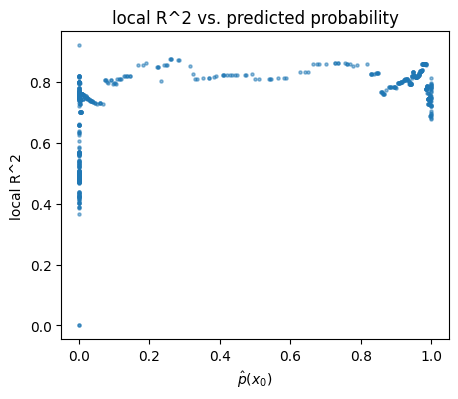

In [8]:
records = []

for i in range(X_test.shape[0]):
    x0 = X_test.iloc[i].values # 設計點 x0，用標準化+SMOTE 後的空間

    sur_model, info = local_surrogate(
        x0=x0,
        blackbox_model=clf,
        scaler=None,
        n_samples=500,
        sigma=1,
        surrogate_type="tree",
        random_state=42
    )
    
    records.append({'local_R2':info["r2"],
                    'local_MSE':info["mse"]})

local_df = pd.DataFrame(records)

idx = np.arange(len(X_test))
p_test = clf.predict_proba(X_test)[:, 1]

local_df["p_hat"] = p_test[idx]

plt.figure(figsize=(5,4))
plt.scatter(local_df["p_hat"], local_df["local_R2"], s=5, alpha=0.5)
plt.xlabel(r"$\hat p(x_0)$")
plt.ylabel("local R^2")
plt.title("local R^2 vs. predicted probability")
plt.show()

c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warni

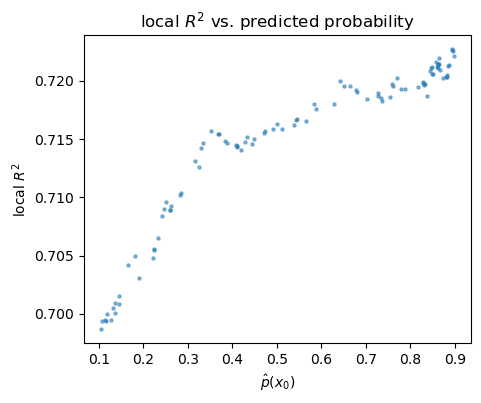

In [56]:
# 設定要取的 x0 個數
K = 100

# 取最接近 decision boundary 的 index
selected_idx = np.argsort(delta)[:K]

# （可選但一致性很重要）固定順序，避免之後對照混亂
selected_idx = np.sort(selected_idx)

records = []

for idx0 in selected_idx:   # selected_idx = 你挑的 p≈0.5 的 index
    x0 = X_test.iloc[idx0].values
    p0 = clf.predict_proba(X_test.iloc[[idx0]])[0, 1]

    sur_model, info = local_surrogate(
        x0=x0,
        blackbox_model=clf,
        scaler=None,
        n_samples=1000,
        sigma=1,
        surrogate_type="tree",
        random_state=42
    )

    records.append({
        "idx": idx0,
        "p_hat": p0,
        "local_R2": info["r2"],
        "local_MSE": info["mse"]
    })

local_df = pd.DataFrame(records)

plt.figure(figsize=(5,4))
plt.scatter(local_df["p_hat"], local_df["local_R2"], s=5, alpha=0.5)
plt.xlabel(r"$\hat p(x_0)$")
plt.ylabel("local $R^2$")
plt.title("local $R^2$ vs. predicted probability")
plt.show()
